### Plotting PCF metrics

- Load pair correlation function (PCF) data
- Apply a consistent lek ordering and labels
- Plot PCF curves with detected meso-scale peaks
- Plot distributions of PCF peak metrics across leks

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
## Output folder for figures
out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

In [3]:
## Load PCF curves and peak table
pcf_all = pd.read_csv("processed_data/pcf_curve_ALL.csv")
peaks = pd.read_csv("processed_data/pcf_peak_table_ALL.csv")

## Factor ordering + labels
lek_order = ['Velavadar_LEK1', 'Velavadar_LEK2', 'TalChhapar_TC']
lek_labels = {'Velavadar_LEK1': 'Velavadar Lek 1','Velavadar_LEK2': 'Velavadar Lek 2','TalChhapar_TC': 'Tal Chhapar'}

pcf_all['lek_id'] = (pd.Categorical(pcf_all['lek_id'],categories=lek_order,ordered=True).rename_categories(lek_labels))
peaks['lek_id'] = (pd.Categorical(peaks['lek_id'],categories=lek_order,ordered=True).rename_categories(lek_labels))

In [7]:
## Colour palettes (matched to R script)
fill_cols = {'Velavadar Lek 1': '#4DAF4A', 'Velavadar Lek 2': '#377EB8', 'Tal Chhapar': '#D6604D'}
point_cols = {'Velavadar Lek 1': '#1B7837', 'Velavadar Lek 2': '#2166AC', 'Tal Chhapar': '#8B1A1A'}
line_cols = point_cols

lek_labels = pcf_all['lek_id'].cat.categories.tolist()

Text(0.02, 0.5, 'g_inhom(r)')

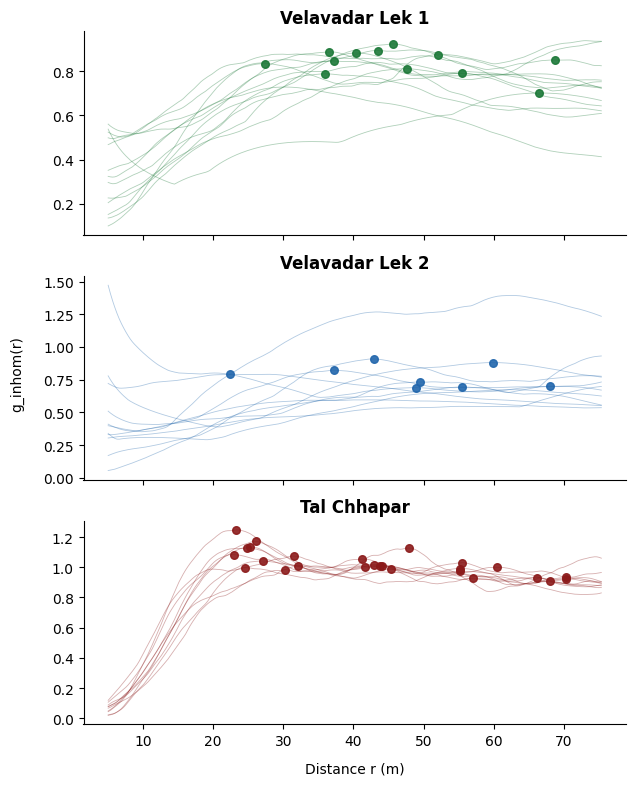

In [10]:
## PCF curves with detected peaks

fig, axes = plt.subplots(len(lek_labels), 1, figsize=(7, 9), sharex=True)

for ax, lek in zip(axes, lek_labels):
    sub_all = pcf_all.loc[pcf_all['lek_id'] == lek]
    sub_peaks = peaks.loc[peaks['lek_id'] == lek]
    
    for _, gdat in sub_all.groupby('date'):
        ax.plot(
            gdat["r"],
            gdat["g"],
            linewidth=0.6,
            alpha=0.35,
            color=line_cols[lek]
        )
    
    ax.scatter(
        sub_peaks["r_peak"],
        sub_peaks["g_peak"],
        s=30,
        color=line_cols[lek],
        alpha=0.9
    )
    
    ax.set_title(lek, fontweight="bold")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel("Distance r (m)", labelpad=10)
fig.text(0.02, 0.5, "g_inhom(r)", va="center", rotation="vertical")

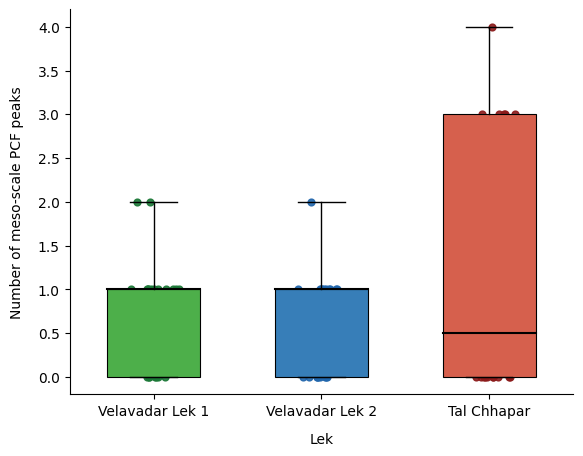

In [22]:
## Number of peaks per date

peak_counts = (
    peaks
    .groupby(['lek_id', "date"], as_index=False)
    .size()
    .rename(columns={"size": "n_peaks"})
)

fig, ax = plt.subplots(figsize=(6.5, 5))

data_by_lek = [
    peak_counts.loc[peak_counts['lek_id'] == lek, "n_peaks"].values
    for lek in lek_labels
]

bp = ax.boxplot(
    data_by_lek,
    widths=0.55,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(linewidth=0.8, edgecolor="black"),
    medianprops=dict(color="black", linewidth=1.5)
)

for patch, lek in zip(bp["boxes"], lek_labels):
    patch.set_facecolor(fill_cols[lek])

for i, lek in enumerate(lek_labels):
    y = peak_counts.loc[peak_counts['lek_id'] == lek, "n_peaks"].values
    x = np.random.normal(i + 1, 0.08, size=len(y))
    ax.scatter(x, y, s=24, color=point_cols[lek], alpha=0.9)

ax.set_xticks(np.arange(1, len(lek_labels) + 1))
ax.set_xticklabels(lek_labels)
ax.set_xlabel('Lek', labelpad=10)
ax.set_ylabel('Number of meso-scale PCF peaks', labelpad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

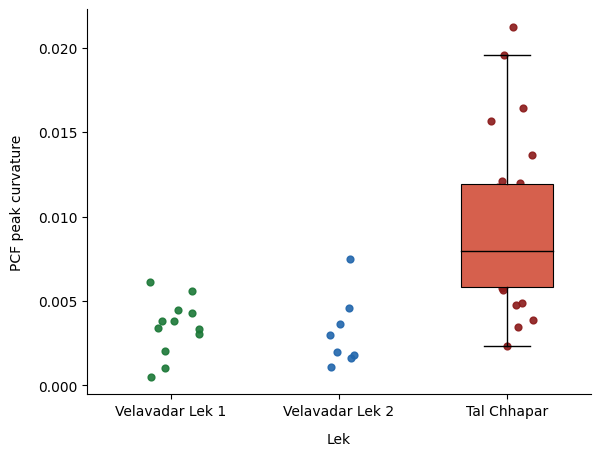

In [18]:
## PCF peak curvature

fig, ax = plt.subplots(figsize=(6.5, 5))

data_by_lek = [
    peaks.loc[peaks['lek_id'] == lek, "peak_curvature"].values
    for lek in lek_labels
]

bp = ax.boxplot(
    data_by_lek,
    widths=0.55,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(linewidth=0.8, edgecolor="black"),
    medianprops=dict(color="black", linewidth=1.0)
)

for patch, lek in zip(bp["boxes"], lek_labels):
    patch.set_facecolor(fill_cols[lek])

for i, lek in enumerate(lek_labels):
    y = peaks.loc[peaks['lek_id'] == lek, "peak_curvature"].values
    x = np.random.normal(i + 1, 0.08, size=len(y))
    ax.scatter(x, y, s=24, color=point_cols[lek], alpha=0.9)

ax.set_xticks(np.arange(1, len(lek_labels) + 1))
ax.set_xticklabels(lek_labels)
ax.set_xlabel('Lek', labelpad=10)
ax.set_ylabel('PCF peak curvature', labelpad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)